# LED Source Modeling

In this section I demonstrate how I model the radiant transfer of energy from the LED using Monte Carlo ray tracing.

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from optiland.rays.real_rays import RealRays

## LED Specs

The LED in this project is a [Thorlabs M450 LP2 LED](https://www.thorlabs.com/item/M450LP2). The key specs are:

  - Wavelength: 450 nm
  - Bandwidth: 18 nm (FWHM)
  - Emission area: 1.5 mm x 1.5 mm
  - Radiant flux: 3 W
  - Viewing angle: 120 degrees

## From a Radiometric to a Probabilistic Model

### Viewing Angle and the Lambertian Order

The most important quantity for modeling the LED is the radiant intensity. (If you're not familiar with radiometry, intensity is the power per solid angle, not per area.) For this I chose a cosine-power law model as a function of the angle with respect to the optical axis:

$$
I( \theta ) \propto \cos^m \theta.
$$

Strictly speaking, the intensity depends on the azimuthal angle $\phi$ as well, but I assume that the intensity is symmetric about the axis so that the dependence on $\phi$ disappears from the expression. The exponent $m$ is known as the "Lambertian order" and is determined by the viewing angle as follows.

Half the viewing angle is the angle at which the intensity drops to half of its maximum value. This happens at $\theta_{1/2} = 60^{\circ}$ for this LED. The value for $m$ is determined by the expression:

$$
\cos^m \theta_{1/2} = 0.5.
$$

Solving for $m$ gives:

$$
m = \frac{-\ln 2}{\ln \cos \theta_{1/2} }
$$

### Spatial and Solid Angle Sampling

The next step is to create an algorithm to generate ray starting locations and angles such that their distributions match the physical model for the LED.

I start with two assumptions:

1. Every point on the emitter surface has the same emission pattern, $ I (\theta) = \cos^m \theta $.
2. The intensity is azimuthally symmetric.

The total power emitted by the LED is the integral of the intensity over the area of the emitter and the solid angle.

$$
\Phi_e = \int_{x=0}^{\ell_x} \int_{y=0}^{\ell_y} \int_{\phi=0}^{2 \pi} \int_{\theta=0}^{\pi/2} I ( \theta ) \sin \theta \, dx \, dy \, d \phi \, d \theta.
$$ (integrated_radiant_flux)

$\sin \theta$ appears because the differential solid angle in spherical coordinates is proportional to $\sin \theta$. $\ell_x$ and $\ell_y$ are the lengths of the rectangular emitter area.

I next assert that if each ray carries equal power $\Phi_e / N$, then the number of rays $n$ emitted from a differential region should be proportional to the power emitted from that region. This leads to a probability distribution:

$$
\frac{n}{N} = p (x, y, \phi, \theta ) \, dx \, dy \, d \phi \, d\theta.
$$

Integrating over this distribution gives:

$$
1 = \int_{x=0}^{\ell_x} \int_{y=0}^{\ell_y} \int_{\phi=0}^{2 \pi} \int_{\theta=0}^{\pi/2} p (x, y, \phi, \theta ) \, dx \, dy \, d \phi \, d \theta.
$$

More generally, since $x$, $y$, $\phi$, and $\theta$ are independent random variables:

$$
p (x, y, \phi, \theta ) = p (x) p(y) p(\phi) p(\theta).
$$

Let $p (x)$, $p (y)$, and $p (\phi)$ be uniformly distributed over $[0, \ell_x]$, $[0, \ell_y]$, and $[0, 2 \pi]$, respectively. Then I have

$$
1 = \frac{A}{2 \pi \ell_x \ell_y} \int_{x=0}^{\ell_x} \int_{y=0}^{\ell_y} \int_{\phi=0}^{2 \pi} \int_{\theta=0}^{\pi/2} p (\theta ) \, dx \, dy \, d \phi \, d \theta
$$ (integrated_probability)

where $A$ is a normalization constant that ensures integration of over $\theta$ is equal to 1. Comparing equations {eq}`integrated_radiant_flux` and {eq}`integrated_probability`, and noting that the number of rays is proportional to the emitted power, I find that

$$
p(\theta) \propto \cos^m \theta \sin \theta.
$$

Integrating over $x$, $y$, and $\phi$:

$$
1 = A \int_0^{\pi / 2} \cos^m \theta \sin \theta \, d \theta.
$$

It remains to

1. determine the normalization constant, and
2. sample from the above probability distribution function to generate the ray starting positions and angles.

### Finding the Value of the Normalization Constant

$$ A \int_0^{\pi / 2} \cos^m \theta \sin \theta \, d \theta = 1 $$

Use substitution of variables with $w = \cos \theta$ and $dw = - \sin \theta$.

$$ -A \int_1^0 w^m \, dw = 1 $$

$$ A \int_0^1 w^m \, dw = 1 $$

$$ \left[ \frac{A w^{m+1}}{m + 1} \right]_0^1 = 1 $$

$$ A = m + 1 $$

Finally, I have the expression for the p.d.f. in $\theta$:

$$
p ( \theta ) = ( m + 1 ) \cos^m \theta \sin \theta
$$ (theta_pdf)

## Inverse Transform Sampling of $p ( \theta) $

To sample from this probability distribution function, I use standard [inverse transform sampling](https://omlc.org/classroom/ece532/class4/sampling.html). In this approach, I draw a uniformly distributed random variable $u$ between 0 and 1, then find for the corresponding value of $\theta$ for which the cumulative distribution function (c.d.f) is equal to $u$.

### The Cumulative Distribution Function $ F ( \theta) $

$$ F ( \theta ) = \int_0^{\theta} (m + 1) \cos^m \theta' \sin \theta' \, d \theta' $$

I solve this using substitution of variables with $ w = \cos \theta' $ and $dw = - \sin \theta'$. The calculation is straight forward.

$$ F ( \theta ) = 1 - \cos^{m+1} \theta $$

### Random Variates Distributed as $ p ( \theta ) $

Let $u$ be a uniformly distributed random number between 0 and 1. Its c.d.f. is just $F( u ) = u$. Then, equating the c.d.f.'s for the uniform random variate and for $\theta$:

$$
u = 1 - \cos^{m+1} \theta.
$$

Solving for $\theta$ leads to the desired expression:

$$
\theta = \arccos \left[ (1 - u)^{1 / (m + 1)} \right]
$$ (inverse_transform_sampling)

This is the key to simulating random numbers for the ray directions that are distributed according to the intensity model of the LED. I draw uniform random numbers $u$, transform them using equation {eq}`inverse_transform_sampling`, and the results are distributed according to equation {eq}`theta_pdf`.

## Ray Generation Algorithm

The following code implements the approach described above.

Note that I have to transform the ray directions in spherical coordinates into the corresponding direction cosines. I also randomly generate wavelengths according to the bandwidth of the LED.

In [2]:
@dataclass
class LED:
    length_x_mm: float = 1.5
    length_y_mm: float = 1.5
    viewing_angle_deg: float = 120.0
    center_wavelength_um: float = 0.45
    fwhm_wavelength_um: float = 0.018

    def lambertian_order(self) -> float:
        """Compute the Lambertian order of the LED from its viewing angle."""
        theta_half_rad = np.deg2rad(self.viewing_angle_deg / 2.0)
        m = -np.log(2) / np.log(np.cos(theta_half_rad))
        return m

    def generate_rays(self, num_rays: int, power_watts: float = 3.0) -> RealRays:
        x_min, x_max = -self.length_x_mm / 2.0, self.length_x_mm / 2.0
        y_min, y_max = -self.length_y_mm / 2.0, self.length_y_mm / 2.0

        # Random starting positions on the LED surface
        x, y = np.random.uniform(x_min, x_max, num_rays), np.random.uniform(y_min, y_max, num_rays)
        z = np.zeros(num_rays)

        # Random directions based on generalized Lambertian distribution
        u, phi = np.random.uniform(0, 1, num_rays), np.random.uniform(0, 2 * np.pi, num_rays)
        theta = np.arccos((1 - u) ** (1 / (self.lambertian_order() + 1)))

        # Direction cosines
        l = np.sin(theta) * np.cos(phi)
        m = np.sin(theta) * np.sin(phi)
        n = np.cos(theta)

        # Ray intensities
        watts_per_ray = power_watts / num_rays

        # Wavelengths
        wavelengths_um = np.random.normal(
            loc=self.center_wavelength_um, scale=self.fwhm_wavelength_um / 2.355, size=num_rays
        )

        return RealRays(x, y, z, l, m, n, watts_per_ray, wavelengths_um)

### Validation

#### Radiant Intensity

Does the radiant intensity go as $I ( \theta) = \cos^m \theta$?

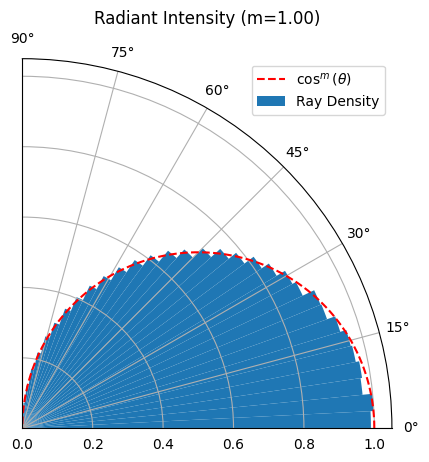

In [3]:
num_rays = 1_000_000
led = LED(viewing_angle_deg=120.0)
rays = led.generate_rays(num_rays=num_rays)

num_bins = 32
bins = np.linspace(0, np.pi / 2, num_bins, endpoint=False)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
width = bins[1] - bins[0]
theta_rays = np.arccos(rays.N)
counts, _ = np.histogram(theta_rays, bins=bins)

solid_angles = 2 * np.pi * (np.cos(bins[:-1]) - np.cos(bins[1:]))
density = counts / solid_angles / num_rays

# Normalize to 1
density_normalized = density / density.max()

ax = plt.subplot(projection='polar')
ax.bar(bin_centers, height=density_normalized, width=width, bottom=0.0, align="center", label="Ray Density")

# Plot cos^m distribution for comparison
theta = np.linspace(0, np.pi / 2, 1000)
m = led.lambertian_order()
ax.plot(theta, np.cos(theta)**m, color='red', linestyle='--', label="$\\cos^m(\\theta)$")
ax.set_thetalim(0, np.pi / 2)

ax.set_title(f"Radiant Intensity (m={m:.2f})")

plt.legend()
plt.show()


#### Ray Azimuthal Directions

Are the ray directions uniformly distributed in the azimuthal dimension?

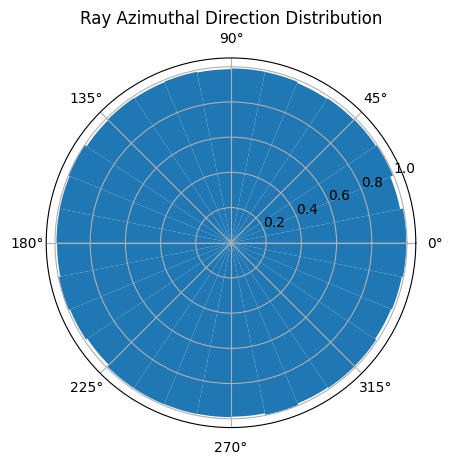

In [4]:
#Are the ray directions uniformly distributed in the azimuthal dimension?

phi_rays = np.arctan2(rays.M, rays.L)
num_bins_azimuth = 32
bins_azimuth = np.linspace(-np.pi, np.pi, num_bins_azimuth + 1)
bin_centers_azimuth = 0.5 * (bins_azimuth[1:] + bins_azimuth[:-1])

counts_azimuth, _ = np.histogram(phi_rays, bins=bins_azimuth)

# Normalize to 1
counts_azimuth_normalized = counts_azimuth / counts_azimuth.max()
width_azimuth = bins_azimuth[1] - bins_azimuth[0]

ax = plt.subplot(projection='polar')
ax.bar(bin_centers_azimuth, height=counts_azimuth_normalized, width=width_azimuth, bottom=0.0, align="center", label="Ray Azimuths")

ax.set_title("Ray Azimuthal Direction Distribution")
plt.show()

#### Ray Starting Positions

Are the ray starting positions uniformly distributed across the emitter surface?

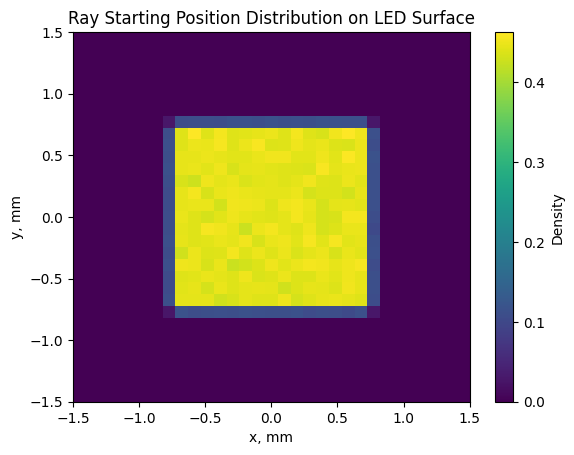

In [5]:
x_positions = rays.x
y_positions = rays.y

num_bins = 32
x_bins = np.linspace(-led.length_x_mm, led.length_x_mm, num_bins)
y_bins = np.linspace(-led.length_y_mm, led.length_y_mm, num_bins)
plt.hist2d(x_positions, y_positions, bins=[x_bins, y_bins], density=True)
plt.xlabel("x, mm")
plt.ylabel("y, mm")
plt.title("Ray Starting Position Distribution on LED Surface")
plt.colorbar(label="Density")
plt.show()

#### Are the wavelengths distributed according to a Gaussian distribution with the correct FWHM?

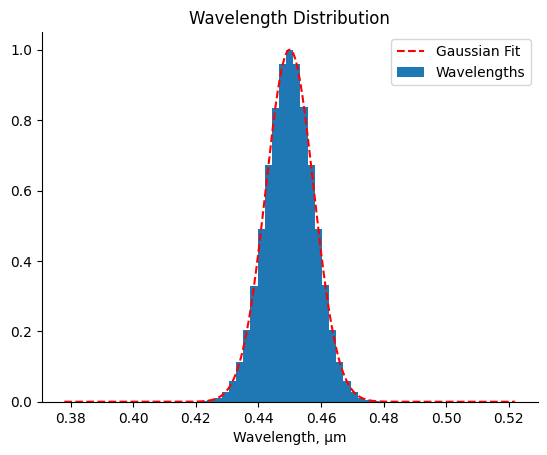

In [6]:
wavelengths_um = rays.w

num_bins_wavelength = 64
wavelength_bins = np.linspace(
    led.center_wavelength_um - 4 * led.fwhm_wavelength_um,
    led.center_wavelength_um + 4 * led.fwhm_wavelength_um,
    num_bins_wavelength,
)
wavelength_bin_centers = 0.5 * (wavelength_bins[1:] + wavelength_bins[:-1])
width_wavelength = wavelength_bins[1] - wavelength_bins[0]

counts_wavelength, _ = np.histogram(wavelengths_um, bins=wavelength_bins)
counts_wavelength_normalized = counts_wavelength / counts_wavelength.max()

ax = plt.subplot()
ax.bar(wavelength_bin_centers, height=counts_wavelength_normalized, width=width_wavelength, bottom=0.0, align="center", label="Wavelengths")

# Plot Gaussian distribution for comparison
sigma_um = led.fwhm_wavelength_um / 2.355
wavelengths_fit = np.linspace(
    led.center_wavelength_um - 4 * led.fwhm_wavelength_um,
    led.center_wavelength_um + 4 * led.fwhm_wavelength_um,
    1000,
)
gaussian_fit = np.exp(-0.5 * ((wavelengths_fit - led.center_wavelength_um) / sigma_um) ** 2)
gaussian_fit /= gaussian_fit.max()
ax.plot(wavelengths_fit, gaussian_fit, color='red', linestyle='--', label="Gaussian Fit")

ax.set_title("Wavelength Distribution")
ax.legend()

ax.set_xlabel("Wavelength, µm")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()